# EDA - Análisis Exploratorio de Datos

## Importación de librerías

In [4]:
## Librerías de manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de rutas
from pathlib import Path

# Configuración de librerías y estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
import warnings
warnings.filterwarnings('ignore')




## Estructura del dataset

In [9]:
# Ruta de los datasets.
DATA_RAW = Path("../data/raw") 

# Carga del dataset.
df_master = pd.read_csv(DATA_RAW / "marvel_master.csv")
df_rag = pd.read_csv(DATA_RAW / "marvel_rag.csv")
df_ratings = pd.read_csv(DATA_RAW / "marvel_ratings.csv")
df_cast = pd.read_csv(DATA_RAW / "marvel_cast.csv")

# Dimensiones de cada dataset.
print(f'El dataset master tiene {df_master.shape[0]} filas y {df_master.shape[1]} columnas.')
print(f'El dataset RAG tiene {df_rag.shape[0]} filas y {df_rag.shape[1]} columnas.')
print(f'El dataset ratings tiene {df_ratings.shape[0]} filas y {df_ratings.shape[1]} columnas.')
print(f'El dataset cast tiene {df_cast.shape[0]} filas y {df_cast.shape[1]} columnas.')


El dataset master tiene 161 filas y 50 columnas.
El dataset RAG tiene 161 filas y 6 columnas.
El dataset ratings tiene 554 filas y 4 columnas.
El dataset cast tiene 1628 filas y 9 columnas.


## Vista general de `marvel_master.csv` (Tabla de hechos)

In [14]:
df_master.head(3)

,id,title,year,imdb_id,type,rated,runtime_min,genre,director,writer,actors,plot,language,country,awards,imdb_rating,imdb_votes,rt_score,metacritic_score,box_office_usd,production,website,mcu_phase,universe,decade,age_years,is_animated,is_tv_series,is_mcu_canon,tmdb_id,tmdb_genres,budget_usd,revenue_usd,tmdb_rating,tmdb_votes,popularity,top5_cast,directors,producers,composer,tmdb_keywords,collection_name,poster_url,production_countries,spoken_languages,episode_count,season_count,network,status,tagline
0,1,Captain America,1944,tt0036697,movie,Approved,244.0,"Action, Adventure, Sci-Fi","Elmer Clifton, John English","Royal K. Cole, Ronald Davidson, Basil Dickey","Dick Purcell, Lorna Gray, Lionel Atwill",Superhero Captain America battles the evil for...,English,United States,NaN,5.3,"1,144",NaN,NaN,NaN,NaN,NaN,Pre-MCU,Pre-MCU,1940s,81,0,0,0,106355.0,"Action, Adventure, Science Fiction",0.0,0.0,5.4,34.0,0.8143,"Dick Purcell, Lorna Gray, Lionel Atwill, Charl...","John English, Elmer Clifton",NaN,NaN,"superhero, based on comic, masked vigilante, m...",NaN,https://image.tmdb.org/t/p/w500/nBRcChS66NohR3...,United States of America,English,NaN,NaN,NaN,Released,NaN
1,2,The Amazing Spider-Man,1977,tt0076975,series,TV-PG,60.0,"Action, Adventure, Crime",NaN,NaN,"Nicholas Hammond, Robert F. Simon, Chip Fields",With the powers given by the bite of a radioac...,English,United States,NaN,6.2,"2,778",NaN,NaN,NaN,NaN,NaN,Pre-MCU,Sony / Spider-Man,1970s,48,0,1,0,225914.0,"Science Fiction, Action, Crime",0.0,0.0,6.3,212.0,1.7517,"Nicholas Hammond, David White, Michael Pataki,...",E.W. Swackhamer,Edward Montagne,Craig Huxley,"mind control, new york city, photographer, sec...",Spider-Man (TV) Collection,https://image.tmdb.org/t/p/w500/jNxRHZ2cxVkNRt...,United States of America,English,NaN,NaN,NaN,Released,The world's favorite adventure super hero in l...
2,3,Spider-Man,1977,tt0076975,series,TV-PG,60.0,"Action, Adventure, Crime",NaN,NaN,"Nicholas Hammond, Robert F. Simon, Chip Fields",With the powers given by the bite of a radioac...,English,United States,NaN,6.2,"2,778",NaN,NaN,NaN,NaN,NaN,Pre-MCU,Sony / Spider-Man,1970s,48,0,1,0,225914.0,"Science Fiction, Action, Crime",0.0,0.0,6.3,212.0,1.7517,"Nicholas Hammond, David White, Michael Pataki,...",E.W. Swackhamer,Edward Montagne,Craig Huxley,"mind control, new york city, photographer, sec...",Spider-Man (TV) Collection,https://image.tmdb.org/t/p/w500/jNxRHZ2cxVkNRt...,United States of America,English,NaN,NaN,NaN,Released,The world's favorite adventure super hero in l...


In [15]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    161 non-null    int64  
 1   title                 161 non-null    object 
 2   year                  161 non-null    int64  
 3   imdb_id               114 non-null    object 
 4   type                  114 non-null    object 
 5   rated                 101 non-null    object 
 6   runtime_min           97 non-null     float64
 7   genre                 113 non-null    object 
 8   director              94 non-null     object 
 9   writer                102 non-null    object 
 10  actors                109 non-null    object 
 11  plot                  108 non-null    object 
 12  language              113 non-null    object 
 13  country               113 non-null    object 
 14  awards                85 non-null     object 
 15  imdb_rating           1

In [16]:
# Nulos por columna, top 15 columnas con más nulos.
df_master.isna().sum().sort_values(ascending=False).head(15)

production          161
website             161
season_count        150
network             150
episode_count       150
box_office_usd       90
metacritic_score     89
collection_name      89
rt_score             83
awards               76
director             67
runtime_min          64
rated                60
imdb_rating          59
writer               59
dtype: int64

Observaciones: Columnas como `box_office_usd`, `rt_score` y `metacritic_score` tienen bastantes nulos. Son fuentes externas que no cubren todo el catálogo, especialmente en producciones antiguas o de TV. `budget_usd`/`revenue_usd` están más completas y son la base para las preguntas ROI.

## Distribución por Fase del MCU

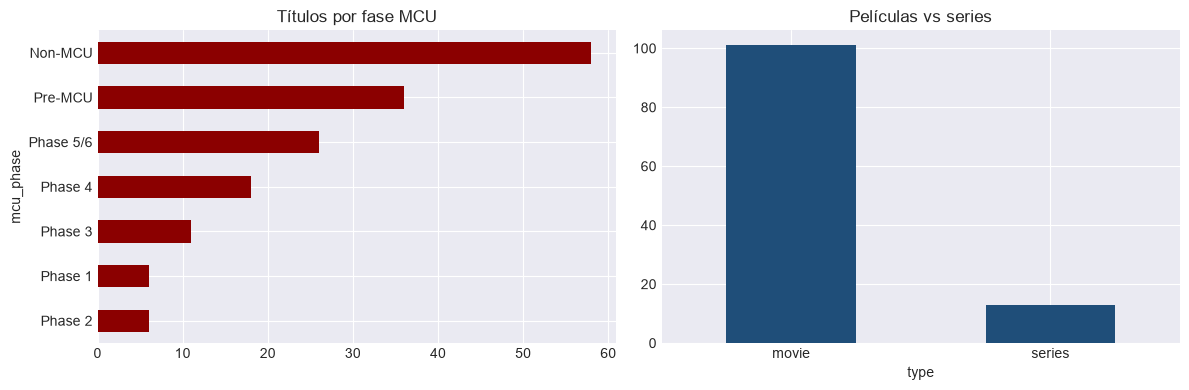

In [17]:
# Configuración del gráfico.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_master['mcu_phase'].value_counts().plot(kind='barh', ax=axes[0], color='#8B0000')
axes[0].set_title('Títulos por fase MCU')
axes[0].invert_yaxis()

df_master['type'].value_counts().plot(kind='bar', ax=axes[1], color='#1f4e79')
axes[1].set_title('Películas vs series')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()